ValueError: x and y must have same first dimension, but have shapes (16384,) and (16385,)

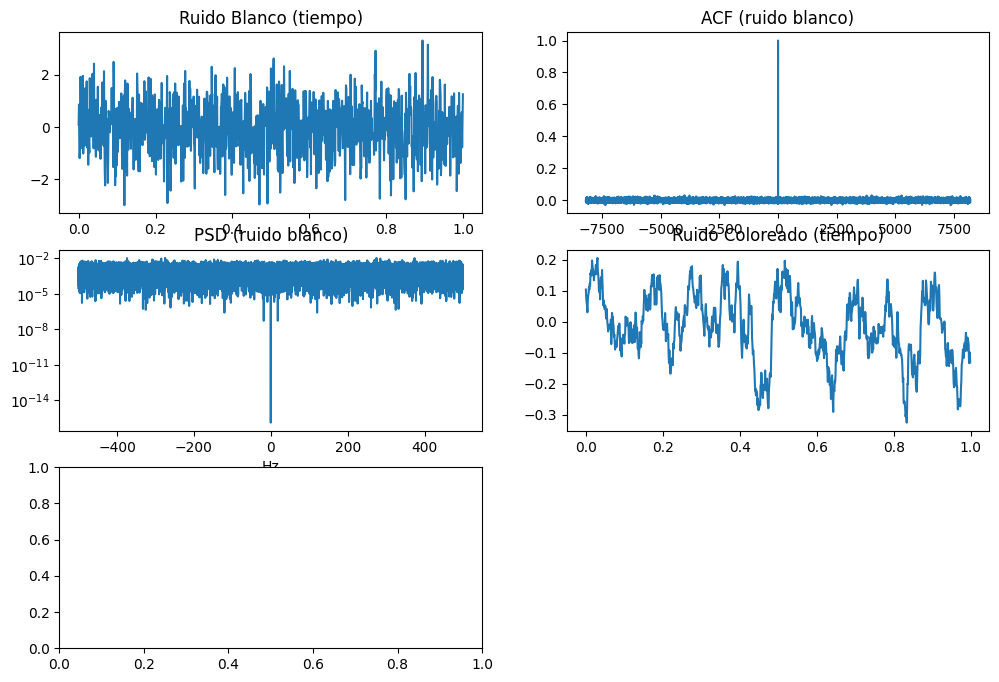

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parámetros
# =========================
N = 2**14              # número de muestras
fs = 1000              # frecuencia de muestreo (Hz)
t = torch.arange(N) / fs

# =========================
# 1. Ruido Blanco Gaussiano
# =========================
mean = 0.0
std = 1.0

x = mean + std * torch.randn(N)

# =========================
# 2. Autocorrelación (ACF)
# =========================
def autocorrelation(signal):
    signal = signal - torch.mean(signal)  # quitar media
    result = torch.fft.ifft(torch.abs(torch.fft.fft(signal))**2).real
    result = torch.fft.fftshift(result)
    result = result / torch.max(result)  # normalización
    return result

acf = autocorrelation(x)
lags = torch.arange(-N//2, N//2)

# =========================
# 3. PSD (correcta)
# =========================
def compute_psd(signal, fs):
    signal = signal - torch.mean(signal)
    X = torch.fft.fft(signal)
    psd = (torch.abs(X)**2) / (fs * len(signal))  # normalización física
    psd = torch.fft.fftshift(psd)
    freqs = torch.fft.fftshift(torch.fft.fftfreq(len(signal), d=1/fs))
    return freqs, psd

freqs, psd = compute_psd(x, fs)

# =========================
# 4. Ruido coloreado (filtro simple)
# =========================
# Filtro pasa bajos (suaviza → introduce correlación)
kernel_size = 50
kernel = torch.ones(kernel_size) / kernel_size

x_colored = torch.conv1d(
    x.view(1,1,-1),
    kernel.view(1,1,-1),
    padding=kernel_size//2
).view(-1)

acf_colored = autocorrelation(x_colored)
freqs_c, psd_colored = compute_psd(x_colored, fs)

# =========================
# 5. Gráficas
# =========================
plt.figure(figsize=(12,8))

# Señal
plt.subplot(3,2,1)
plt.plot(t[:1000], x[:1000])
plt.title("Ruido Blanco (tiempo)")

# ACF
plt.subplot(3,2,2)
plt.plot(lags, acf)
plt.title("ACF (ruido blanco)")

# PSD
plt.subplot(3,2,3)
plt.semilogy(freqs, psd)
plt.title("PSD (ruido blanco)")
plt.xlabel("Hz")

# Ruido coloreado
plt.subplot(3,2,4)
plt.plot(t[:1000], x_colored[:1000])
plt.title("Ruido Coloreado (tiempo)")

# ACF coloreado
plt.subplot(3,2,5)
plt.plot(lags, acf_colored)
plt.title("ACF (coloreado)")

# PSD coloreado
plt.subplot(3,2,6)
plt.semilogy(freqs_c, psd_colored)
plt.title("PSD (coloreado)")
plt.xlabel("Hz")

plt.tight_layout()
plt.show()